In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import getpass
import act

In [2]:
if "ARM_USERNAME" in os.environ:
    arm_username = os.getenv("ARM_USERNAME")
else:
    arm_username = input("Enter ARM username: ").strip()
if "ARM_TOKEN" in os.environ:
    arm_token = os.getenv("ARM_TOKEN")
else:
    arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

Enter ARM username:  ssingh45
Enter ARM token (hidden):  ········


In [4]:
# Set the datastream and start/enddates
# mw1 = 'nsamwrlosC1.b1'  ## mwrlos
# mw2 = "nsamwrret1liljclouC1.c2"  ## MWRRET1LILJCLOU
# mw3 = "nsamwrhfC1.b1"  #"MWRHF"
# weather_data = "nsametC1.b1"
cloud_phase = "nsathermocldphaseC1"

startdate = '2015-06-09'
enddate = '2015-06-18'

# Use ACT to easily download the data.  Watch for the data citation!  Show some support
# for ARM's instrument experts and cite their data if you use it in a publication
# result_mr1 = act.discovery.download_arm_data(arm_username, arm_token, mw1, startdate, enddate)
# print('1')
# result_mr2 = act.discovery.download_arm_data(arm_username, arm_token, mw2, startdate, enddate)
# print('2')
# result_mr3 = act.discovery.download_arm_data(arm_username, arm_token, mw3, startdate, enddate)
# print('3')
# wd_1 = act.discovery.download_arm_data(arm_username, arm_token, weather_data, startdate, enddate)
# print('1')

cloud_phase_1 = act.discovery.download_arm_data(arm_username, arm_token, cloud_phase, startdate, enddate)
print('cloud_phase')

[DOWNLOADING] nsathermocldphaseC1.c0.20150609.000000.nc
[DOWNLOADING] nsathermocldphaseC1.c0.20150610.000000.nc
[DOWNLOADING] nsathermocldphaseC1.c0.20150611.000000.nc
[DOWNLOADING] nsathermocldphaseC1.c0.20150612.000000.nc
[DOWNLOADING] nsathermocldphaseC1.c0.20150613.000000.nc
[DOWNLOADING] nsathermocldphaseC1.c0.20150614.000000.nc
[DOWNLOADING] nsathermocldphaseC1.c0.20150615.000000.nc
[DOWNLOADING] nsathermocldphaseC1.c0.20150616.000000.nc
[DOWNLOADING] nsathermocldphaseC1.c0.20150617.000000.nc
[DOWNLOADING] nsathermocldphaseC1.c0.20150618.000000.nc

If you use these data to prepare a publication, please cite:

Please check your arguments. No DOI Found

cloud_phase


In [5]:
cloud_phase = act.io.read_arm_netcdf(cloud_phase_1)["cloud_phase_mplgr"]

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed


In [6]:
start_time = "2015-06-10T00:00"
end_time = "2015-06-11T00:00"
time_array = np.arange(start_time, end_time, dtype="datetime64[s]", step=30)

cloud_phase_label = cloud_phase.interp(time=time_array, method='nearest')

In [7]:
cloud_phase_label.shape, cloud_phase_label.height

((2880, 596),
 <xarray.DataArray 'height' (height: 596)> Size: 2kB
 array([ 0.16,  0.19,  0.22, ..., 17.95, 17.98, 18.01], dtype=float32)
 Coordinates:
   * height   (height) float32 2kB 0.16 0.19 0.22 0.25 ... 17.95 17.98 18.01
 Attributes:
     long_name:      Height above ground level
     units:          km
     standard_name:  height)

In [8]:
# flag_values :
#     [0 1 2 3 4 5 6 7 8]
# flag_meanings :
# clear_sky:0, > 0
# liquid:1 > 1
# ice:2 > 2
# mixed_phase:3 >3
# drizzle:4 > 1
# liquid_drizzle:5 > 1
# rain:6 >1 
# snow:7> 2
# unknown:8> 4

In [9]:
# clear_sky:0
# liquid, drizzle, liquid_drizzle, rain:1
# ice:2
# mixed_phase:3
# unknown:4

In [10]:
cloud_phase_label1 = xr.where(cloud_phase_label==4, 1, cloud_phase_label)
cloud_phase_label1 = xr.where(cloud_phase_label1==5, 1, cloud_phase_label1)
cloud_phase_label1 = xr.where(cloud_phase_label1==6, 1, cloud_phase_label1)
cloud_phase_label1 = xr.where(cloud_phase_label1==7, 2, cloud_phase_label1)
cloud_phase_label1 = xr.where(cloud_phase_label1==8, 4, cloud_phase_label1)

(<matplotlib.collections.QuadMesh at 0x7f0374fd3d10>, (2880, 596))

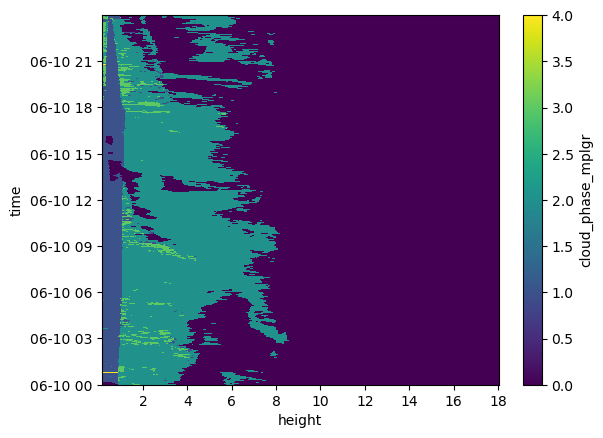

In [11]:
cloud_phase_label1.plot(), cloud_phase_label1.shape

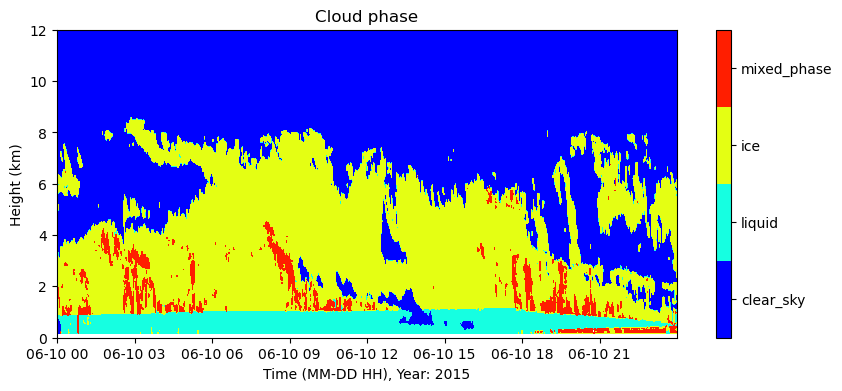

In [12]:
xx = cloud_phase_label1
plt.figure(figsize=(10, 4))
levels = [0.0, 1.0, 2.0, 3.0, 4.0]
contour_filled = plt.contourf(np.array(xx.time), np.array(xx.height), np.array(xx.transpose())+0.5, levels=levels, cmap="jet")

# 3. Create the colorbar
cbar = plt.colorbar(contour_filled)
cbar.set_ticks(np.array([0.0, 1.0, 2.0, 3.0])+0.5)

# 5. Replace those tick positions with your custom text
cbar.set_ticklabels(["clear_sky", "liquid", "ice", "mixed_phase"])

plt.title('Cloud phase')
plt.xlabel('Time (MM-DD HH), Year: 2015')
plt.ylabel('Height (km)')
plt.ylim(0, 12)
plt.show()



In [13]:
cloud_phase_label1.to_netcdf("cloud_phase_label.nc")

In [14]:
cloud_phase_label1.shape, cloud_phase_label1.height

((2880, 596),
 <xarray.DataArray 'height' (height: 596)> Size: 2kB
 array([ 0.16,  0.19,  0.22, ..., 17.95, 17.98, 18.01], dtype=float32)
 Coordinates:
   * height   (height) float32 2kB 0.16 0.19 0.22 0.25 ... 17.95 17.98 18.01)

In [15]:
np.where(np.int32(cloud_phase_label1).flatten()==0)[0].shape, 

((1234149,),)

In [16]:
np.where(np.int32(cloud_phase_label1).flatten()==1)[0].shape

(74888,)

In [17]:
np.where(np.int32(cloud_phase_label1).flatten()==2)[0].shape

(387959,)

In [18]:
np.where(np.int32(cloud_phase_label1).flatten()==3)[0].shape

(19249,)

In [19]:
np.where(np.int32(cloud_phase_label1).flatten()==4)[0].shape

(235,)

## radar data

In [20]:
data_ref_dataset = xr.open_dataset("nsaarsclkazr1kolliasC1.c0.20150610.000000_subset.nc")
data_refl_radar= data_ref_dataset["reflectivity_best_estimate"].interp(time=time_array)
data_refl_radar.to_netcdf("data_refl_radar.nc")

In [21]:
data_refl_radar.shape, data_refl_radar.height

((2880, 596),
 <xarray.DataArray 'height' (height: 596)> Size: 2kB
 array([  160.,   190.,   220., ..., 17950., 17980., 18010.], dtype=float32)
 Coordinates:
   * height   (height) float32 2kB 160.0 190.0 220.0 ... 1.798e+04 1.801e+04
 Attributes:
     long_name:      Height above ground level
     units:          m
     standard_name:  height)

In [22]:
data_ref_dataset["spectral_width"].interp(time=time_array).to_netcdf("spectral_width_radar.nc")
data_ref_dataset["mean_doppler_velocity"].interp(time=time_array).to_netcdf("mean_doppler_vel_radar.nc")

## ceilometer

In [23]:
data_ceil = xr.open_dataset("ceilometer10June2015.nc")
data_ceil1 = data_ceil['backscatter'].interp(time = time_array)
data_ceil1.to_netcdf("data_ceilometer.nc")

In [24]:
data_ceil1.shape, data_ceil1.height

((2880, 252),
 <xarray.DataArray 'height' (height: 252)> Size: 1kB
 array([  15.,   45.,   75., ..., 7485., 7515., 7545.], dtype=float32)
 Coordinates:
   * height   (height) float32 1kB 15.0 45.0 75.0 ... 7.515e+03 7.545e+03)

## radiometer lwp

In [25]:
mw1 = 'nsamwrlosC1.b1'  ## mwrlos
mr1 = act.discovery.download_arm_data(arm_username, arm_token, mw1, startdate, enddate)
mr1_dataset = act.io.read_arm_netcdf(mr1)

[DOWNLOADING] nsamwrlosC1.b1.20150609.000000.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150610.000040.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150611.000000.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150612.000011.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150613.000005.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150614.000000.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150615.000000.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150616.000000.cdf
[DOWNLOADING] nsamwrlosC1.b1.20150617.000017.cdf

If you use these data to prepare a publication, please cite:

Cadeddu, M. Microwave Radiometer (MWRLOS), 2015-06-09 to 2015-06-18, North Slope
Alaska (NSA), Central Facility, Barrow AK (C1). Atmospheric Radiation
Measurement (ARM) User Facility. https://doi.org/10.5439/1999490



In [26]:
liq_water_path = mr1_dataset['liq'].interp(time = time_array)
liq_water_path.to_netcdf("lwp_mwr.nc")

In [27]:
liq_water_path.time

<xarray.DataArray 'time' (time: 2880)> Size: 23kB
array(['2015-06-10T00:00:00', '2015-06-10T00:00:30', '2015-06-10T00:01:00',
       ..., '2015-06-10T23:58:30', '2015-06-10T23:59:00',
       '2015-06-10T23:59:30'], dtype='datetime64[s]')
Coordinates:
  * time     (time) datetime64[s] 23kB 2015-06-10 ... 2015-06-10T23:59:30
Attributes:
    long_name:  Time offset from midnight